# 1. Data Cleaning

Data cleaning is the first stage of the Credit Risk & Data Quality Analytics project. The objective is to transform the raw credit-risk dataset into a reliable and analysis-ready dataset.

The cleaning process includes:

- Loading and inspecting the raw dataset
- Understanding the dataset structure
- Checking data types
- Identifying missing values
- Detecting duplicate records
- Checking invalid and inconsistent values
- Identifying outliers
- Handling missing and invalid data
- Converting columns to appropriate data types
- Validating the cleaned dataset
- Exporting the cleaned dataset for further analysis

The original dataset is preserved without modification, while all cleaning operations are performed on a working copy.

### 1.1 Import Required Libraries

The following Python libraries are used for data manipulation, numerical analysis, and visualization.

- Pandas is used for data loading, manipulation, and cleaning.
- NumPy is used for numerical operations.
- Matplotlib and Seaborn are used to visualize distributions and identify potential outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Load the Raw Dataset

The credit risk dataset downloaded from Kaggle is loaded into a Pandas DataFrame.

The raw dataset is treated as the source dataset and is not modified directly. A separate working copy will be created for the cleaning process.

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 1.3 Create a Working Copy

A copy of the raw dataset is created before performing any transformations. This ensures that the original data remains unchanged and can be used for comparison and validation.

In [4]:
df_clean = df.copy()

### 1.4 Dataset Overview

The first step in understanding the dataset is to examine its dimensions and structure.

The number of rows represents the number of loan applications, while the columns represent applicant, loan, and credit-related attributes.

In [5]:
print("Number of rows:", df_clean.shape[0])
print("Number of columns:", df_clean.shape[1])

Number of rows: 32581
Number of columns: 12


In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [8]:
df_clean.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


### 1.5 Check Column Names

Column names are reviewed to understand the available variables and identify any naming inconsistencies that may affect subsequent analysis.

In [9]:
df_clean.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

### 1.6 Missing Value Analysis

Missing values can affect statistical analysis, visualizations, and machine learning models. Therefore, each column is examined for missing observations.

Both the number and percentage of missing values are calculated to understand the extent of missing data.

In [10]:
missing_values = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": (df_clean.isnull().sum() / len(df_clean)) * 100
})
missing_values.sort_values("Missing Values", ascending=False)

,Missing Values,Missing Percentage
loan_int_rate,3116,9.563856
person_emp_length,895,2.747000
person_income,0,0.000000
person_age,0,0.000000
person_home_ownership,0,0.000000
loan_intent,0,0.000000
loan_grade,0,0.000000
loan_amnt,0,0.000000
loan_status,0,0.000000
loan_percent_income,0,0.000000


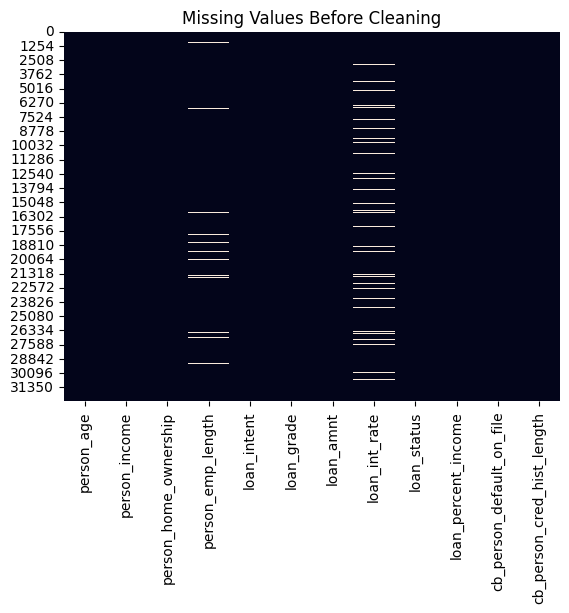

In [11]:
sns.heatmap(df_clean.isnull(), cbar=False)
plt.title("Missing Values Before Cleaning")
plt.show()

### 1.7 Handling Missing Values

Missing numerical values are handled using the median of the respective column.

The median is preferred over the mean because credit-related variables such as income, loan amount, and employment length may contain skewed distributions and extreme observations.

Categorical missing values, if present, are handled using the mode.

In [12]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns
for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

In [13]:
categorical_columns = df_clean.select_dtypes(include="object").columns
for column in categorical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

In [14]:
df_clean.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


### 1.8 Duplicate Record Analysis

Duplicate records can result in double-counting and may distort statistical analysis and model performance.

The dataset is therefore checked for completely duplicated rows.

In [15]:
duplicate_count = df_clean.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 165


In [16]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Dataset shape after removing duplicates:", df_clean.shape)

Dataset shape after removing duplicates: (32416, 12)


### 1.9 Data Type Validation

Each column is checked to ensure that its data type is appropriate for analysis.

Numerical variables should be stored as numeric data types, while categorical variables should be represented as categorical or object data types.

In [17]:
df_clean.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


### 1.10 Data Type Conversion

Columns are converted to appropriate data types where necessary.

Integer columns are used for discrete numerical variables, while floating-point columns are retained for continuous financial variables such as income, loan amount, and interest rate.

In [18]:
df_clean = df_clean.convert_dtypes()
df_clean.dtypes

,0
person_age,Int64
person_income,Int64
person_home_ownership,string[python]
person_emp_length,Int64
loan_intent,string[python]
loan_grade,string[python]
loan_amnt,Int64
loan_int_rate,Float64
loan_status,Int64
loan_percent_income,Float64


### 1.11 Numerical Data Validation

Credit-risk data should satisfy basic logical conditions.

For example:

- Applicant age should be positive.
- Income should be greater than zero.
- Loan amount should be greater than zero.
- Interest rate should not be negative.
- Employment length should not be negative.
- Loan-to-income percentage should not be negative.

In [19]:
print("Negative age:", (df_clean["person_age"] < 0).sum())
print("Negative income:", (df_clean["person_income"] < 0).sum())
print("Negative employment length:", (df_clean["person_emp_length"] < 0).sum())
print("Negative loan amount:", (df_clean["loan_amnt"] < 0).sum())
print("Negative interest rate:", (df_clean["loan_int_rate"] < 0).sum())
print("Negative loan percent income:", (df_clean["loan_percent_income"] < 0).sum())

Negative age: 0
Negative income: 0
Negative employment length: 0
Negative loan amount: 0
Negative interest rate: 0
Negative loan percent income: 0


### 1.12 Categorical Value Validation

Categorical variables are examined to identify unexpected, inconsistent, or incorrectly entered categories.

This validation helps maintain consistency during SQL analysis, visualization, and machine learning.

In [20]:
categorical_columns = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]
for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts())


person_home_ownership
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: Int64

loan_intent
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: Int64

loan_grade
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: Int64

cb_person_default_on_file
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: Int64


### 1.13 Loan Status Validation

The `loan_status` variable represents the loan outcome.

The distribution of the target variable is examined to verify that it contains the expected binary categories and to understand the proportion of default and non-default loans.

In [21]:
df_clean["loan_status"].value_counts()

,count
loan_status,
0,25327
1,7089


In [22]:
df_clean["loan_status"].value_counts(normalize=True) * 100

,proportion
loan_status,
0,78.13117
1,21.86883


### 1.14 Outlier Detection

Outliers are observations that differ substantially from the majority of the data.

In credit-risk datasets, variables such as applicant income, age, loan amount, and employment length may contain extreme observations.

Outliers are first identified rather than automatically removed because extreme financial values can represent legitimate applicants.

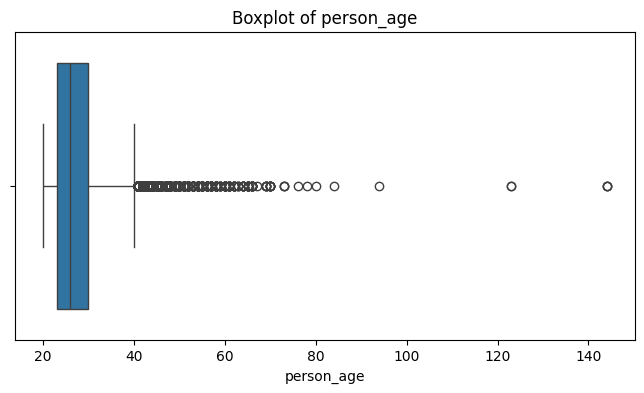

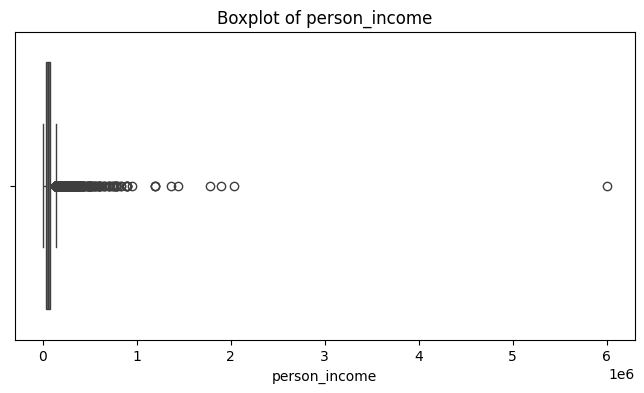

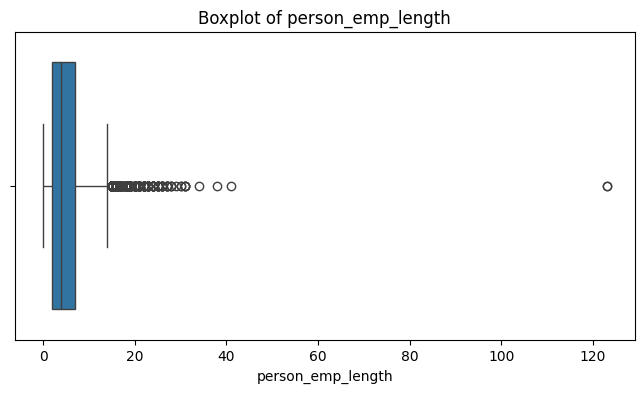

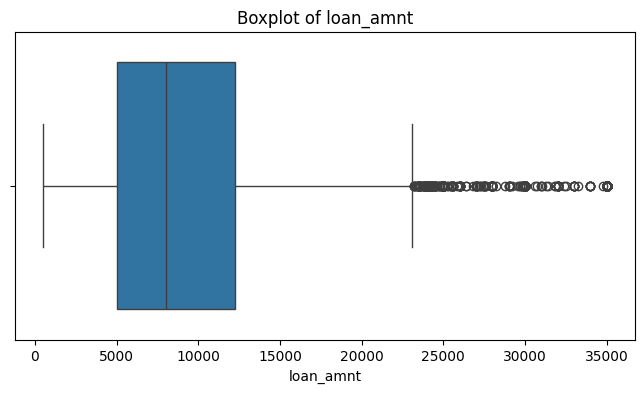

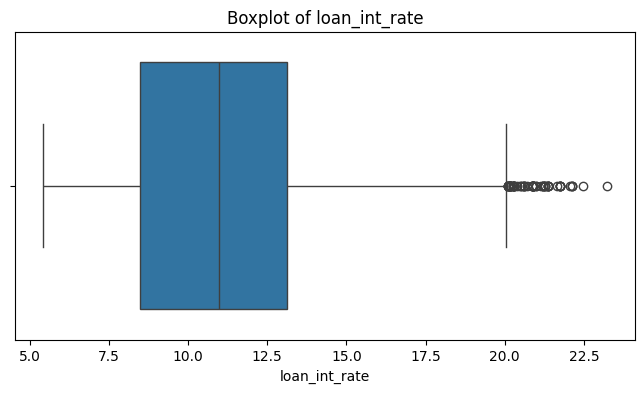

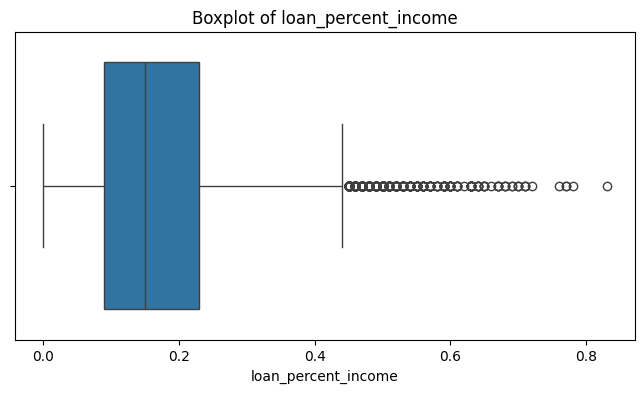

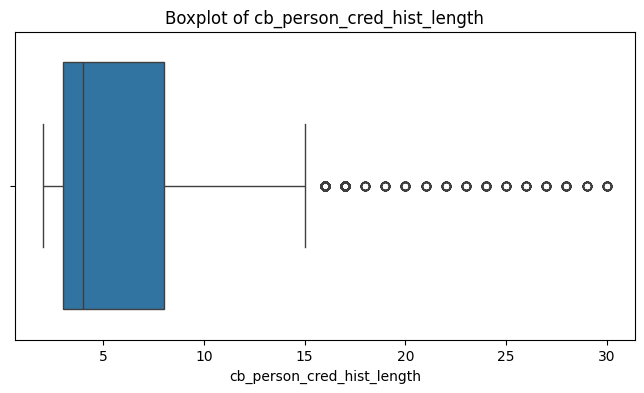

In [23]:
numeric_columns = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_clean[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

### 1.15 Quantitative Outlier Detection

The Interquartile Range (IQR) method is used to identify potential outliers.

The lower boundary is calculated as Q1 − 1.5 × IQR, while the upper boundary is calculated as Q3 + 1.5 × IQR.

Observations outside these boundaries are flagged as potential outliers.

In [24]:
outlier_summary = []

for column in numeric_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df_clean[column] < lower_bound) |
                (df_clean[column] > upper_bound)).sum()
    outlier_summary.append([
        column,
        outliers,
        round((outliers / len(df_clean)) * 100, 2)
    ])
outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Outlier Count", "Outlier Percentage"]
)
outlier_summary

,Column,Outlier Count,Outlier Percentage
0,person_age,1491,4.60
1,person_income,1478,4.56
2,person_emp_length,852,2.63
3,loan_amnt,1679,5.18
4,loan_int_rate,70,0.22
5,loan_percent_income,650,2.01
6,cb_person_cred_hist_length,1139,3.51


### 1.16 Handling Extreme Values

Outlier detection is used as a diagnostic step rather than automatically removing every extreme observation.

Legitimate high-income applicants or large loan applications may naturally appear as statistical outliers. Therefore, observations are removed only when they violate logical or domain-related constraints.

This approach prevents the unnecessary loss of valid credit-risk information.

In [25]:
df_clean = df_clean[
    (df_clean["person_age"] > 0) &
    (df_clean["person_income"] > 0) &
    (df_clean["person_emp_length"] >= 0) &
    (df_clean["loan_amnt"] > 0) &
    (df_clean["loan_int_rate"] >= 0) &
    (df_clean["loan_percent_income"] >= 0)
].reset_index(drop=True)

### 1.17 Post-Cleaning Validation

After completing the cleaning process, the dataset is checked again for missing values and duplicate records.

This confirms whether the primary cleaning operations have been successfully applied.

In [26]:
print("Missing values:")
print(df_clean.isnull().sum())
print("\nDuplicate rows:", df_clean.duplicated().sum())

Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Duplicate rows: 0


### 1.18 Before and After Comparison

The dimensions of the original and cleaned datasets are compared to quantify the changes made during the cleaning process.

In [27]:
comparison = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Before Cleaning": [df.shape[0], df.shape[1]],
    "After Cleaning": [df_clean.shape[0], df_clean.shape[1]]
})
comparison

,Metric,Before Cleaning,After Cleaning
0,Rows,32581,32416
1,Columns,12,12


### 1.19 Final Dataset

The cleaned dataset is inspected to ensure that the structure, values, and data types are suitable for downstream analysis.

The resulting dataset will be used for exploratory data analysis, data-quality assessment, SQL analysis, credit-risk analysis, and machine learning.

In [28]:
df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.1,N,2
2,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [29]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32416 entries, 0 to 32415
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  Int64  
 1   person_income               32416 non-null  Int64  
 2   person_home_ownership       32416 non-null  string 
 3   person_emp_length           32416 non-null  Int64  
 4   loan_intent                 32416 non-null  string 
 5   loan_grade                  32416 non-null  string 
 6   loan_amnt                   32416 non-null  Int64  
 7   loan_int_rate               32416 non-null  Float64
 8   loan_status                 32416 non-null  Int64  
 9   loan_percent_income         32416 non-null  Float64
 10  cb_person_default_on_file   32416 non-null  string 
 11  cb_person_cred_hist_length  32416 non-null  Int64  
dtypes: Float64(2), Int64(6), string(4)
memory usage: 3.2 MB


In [30]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32416.0,27.747008,6.3541,20.0,23.0,26.0,30.0,144.0
person_income,32416.0,66091.640826,62015.580269,4000.0,38542.0,55000.0,79218.0,6000000.0
person_emp_length,32416.0,4.76888,4.090411,0.0,2.0,4.0,7.0,123.0
loan_amnt,32416.0,9593.845632,6322.730241,500.0,5000.0,8000.0,12250.0,35000.0
loan_int_rate,32416.0,11.014662,3.08305,5.42,8.49,10.99,13.11,23.22
loan_status,32416.0,0.218688,0.413363,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32416.0,0.17025,0.106812,0.0,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32416.0,5.811297,4.05903,2.0,3.0,4.0,8.0,30.0


### 1.20 Export Cleaned Dataset

The cleaned dataset is exported as a CSV file and will serve as the processed dataset for the remaining stages of the project.

The original Kaggle dataset remains unchanged in the raw-data directory.

In [31]:
import os
os.makedirs("data/processed", exist_ok=True)
df_clean.to_csv(
    "data/processed/credit_risk_cleaned.csv",
    index=False
)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [32]:
files.download("data/processed/credit_risk_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Conclusion**

* The raw credit risk dataset was systematically examined to understand its structure, variables, data types, and overall quality.
* Missing values were identified and appropriately handled to ensure completeness and reliability of the dataset.
* Duplicate records were detected and removed to prevent redundant observations from affecting subsequent analysis.
* Numerical and categorical variables were validated to identify invalid, inconsistent, and logically incorrect values.
* Potential outliers were identified using the Interquartile Range (IQR) method and were evaluated without unnecessarily removing legitimate financial observations.
* The `loan_status` target variable was validated to ensure consistency for subsequent credit risk analysis and machine learning.
* Data types were standardized to ensure that numerical and categorical variables could be processed correctly.
* After cleaning and validation, the dataset was transformed into a structured and analysis-ready format.
* The cleaned dataset provides a reliable foundation for Exploratory Data Analysis, Data Quality Assessment, SQL Analysis, Credit Risk Analysis, and Machine Learning.
